In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from Bio.Seq import Seq
from evo.dataset import CherriesDataset, EncodedPEINTDataset
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ete3 import Tree

tqdm.pandas()

from plmr.data.datamodule import PLMRDataModule
from plmr.models.frameworks.peint import load_from_new_checkpoint, simulate_evolution_with_rejection_sampling

/scratch/users/stephen.lu/uv-envs/plm/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/scratch/users/stephen.lu/uv-envs/plm/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Load trained models from checkpoints
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/logs/train/runs")
ckpt_paths = {
    "heavy": ckpt_dir / "2025-08-08_15-36-04/checkpoints/epoch_089.ckpt",
    "light": ckpt_dir / "2025-08-10_11-57-18/checkpoints/epoch_042.ckpt",
    "joint": ckpt_dir / "2025-08-10_11-58-46/checkpoints/epoch_044.ckpt",
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

modules = {k: load_from_new_checkpoint(v, device) for k, v in ckpt_paths.items()}
vocab = next(iter(modules.values())).net.vocab

Using device: cuda


/accounts/projects/yss/stephen.lu/protevo/plmr/plmr/models/frameworks/peint.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map

In [17]:
data_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/data/wyatt/indels")
data_files = {
    "heavy": data_dir / "edges_heavy/d4.txt",
    "light": data_dir / "edges_light/d4.txt",
    "joint": data_dir / "edges_joint/d4.txt",
}

In [5]:
datasets = {
    k: EncodedPEINTDataset(
        dataset=CherriesDataset(data_file=data_files[k]),
        vocab=vocab,
        mask_prob=0.15,
        leave_unmasked_prob=0.0,
        random_token_prob=0.0,
    )
    for k in modules.keys()
}
generators = {
    k: iter(
        PLMRDataModule(
            dataset=v,
            batch_size=32,
            shuffle=False,
        )._dataloader_template(dataset=v, training=False)
    )
    for k, v in datasets.items()
}

In [6]:
df_edges = pd.read_csv(data_dir / "peint_df.csv.gz", compression="gzip")
df_edges = df_edges[df_edges['sample_id'] == 'd4']
df_edges = df_edges[
    (df_edges.parent_heavy_aa != df_edges.child_heavy_aa)
    | (df_edges.parent_light_aa != df_edges.child_light_aa)
]

for i in range(5):
    print(df_edges.iloc[i]["branch_length"], end=" ")
    print(datasets["heavy"][i][4])  # 4th is t

1.4165657723136795 1.4165657723136795
3.928860376069267 3.928860376069267
0.2038963736381347 0.2038963736381347
2.289122312441579 2.289122312441579
0.9847852163741 0.9847852163741001


In [6]:
# Calculate log likelihoods for each sequence type
n_batches = len(next(iter(generators.values())))  # Number of batches in the dataset
lls = defaultdict(list)

for i in tqdm(range(n_batches)):
    for j, seqtype in enumerate(modules.keys()):
        module = modules[seqtype]
        generator = generators[seqtype]
        batch = next(generator)
        batch = [b.to(device) for b in batch]
        [x, x_targets, y, y_targets, t, x_pad_mask, y_pad_mask] = batch

        yt_mask = y_targets != module.net.vocab.pad_idx  # actual values

        with torch.no_grad():
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                x_logits, y_logits = module(x, y, t, x_pad_mask, y_pad_mask)

        # Calculate log probabilities predicted by the model
        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)

        nll = F.cross_entropy(
            y_logits.transpose(-1, -2),
            y_targets,
            ignore_index=vocab.pad_idx,
            reduction="none",
        )  # keep unreduced to get per-site time likelihood

        ll = -nll * yt_mask.float()  # log likelihoods (bs, seq_len)
        ll = ll.sum(dim=-1)  # sum over sequence length (bs,)

        lls[seqtype].append(ll.detach().cpu().numpy())

  0%|                                                                                             | 0/300 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 300/300 [01:10<00:00,  4.28it/s]


In [7]:
# save the likelihoods back into the dataframe
lls = {k: np.concatenate(v) for k, v in lls.items()}
for k, v in lls.items():
    df_edges[f"ll_{k}"] = v

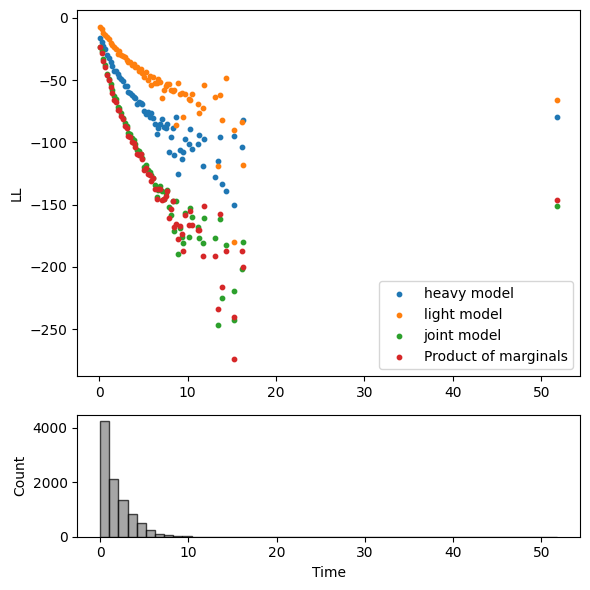

In [8]:
# plot the binned likelihoods according to the branch length
df_edges["time_bin"] = df_edges.branch_length // df_edges.branch_length.quantile(0.1).astype(float)
bin_cols = ['time_bin', 'branch_length'] + [f'll_{k}' for k in lls.keys()]
binned_df = df_edges[bin_cols].groupby("time_bin").mean()

fig, (ax_main, ax_histx) = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(6, 6))

# Main scatter plot
for seqtype in lls.keys():
    ax_main.scatter(binned_df.branch_length, binned_df[f"ll_{seqtype}"], label=f"{seqtype} model", s=10)

if "ll_heavy" in binned_df.columns and "ll_light" in binned_df.columns:
    ax_main.scatter(
        binned_df.branch_length,
        binned_df.ll_heavy + binned_df.ll_light,
        label="Product of marginals",
        s=10,
    )

ax_main.set_ylabel("LL")
ax_main.legend()

# Histogram on x-axis showing distribution of actual time values
ax_histx.hist(df_edges.branch_length, bins=50, alpha=0.7, color="gray", edgecolor="black")
ax_histx.set_ylabel("Count")
ax_histx.set_xlabel("Time")

plt.tight_layout()
plt.show()

In [12]:
df_edges["n_ins_joint"] = df_edges["n_ins_heavy"] + df_edges["n_ins_light"]
df_edges["n_del_joint"] = df_edges["n_del_heavy"] + df_edges["n_del_light"]
df_edges["n_sub_joint"] = df_edges["n_sub_heavy"] + df_edges["n_sub_light"]

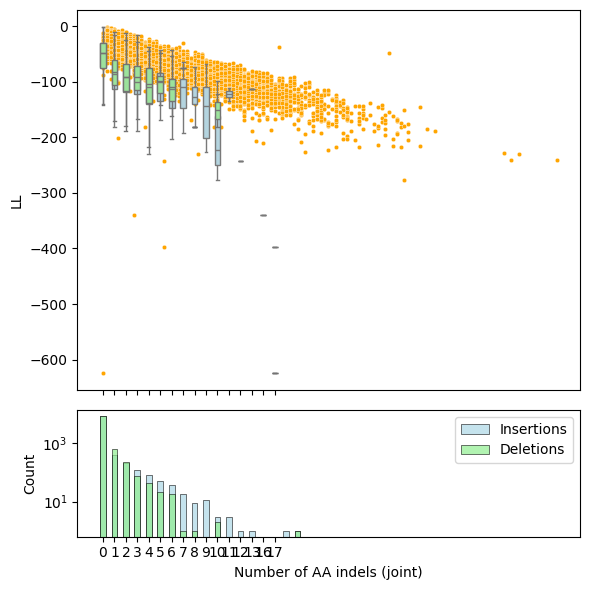

In [14]:
seqtype = 'joint'

# plot the likelihoods by the number of inserts
fig, (ax_main, ax_histx) = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(6, 6), sharex=True)
sns.boxplot(
    df_edges,
    x=df_edges[f'n_ins_{seqtype}'] // 3,
    y=df_edges[f'll_{seqtype}'],
    ax=ax_main,
    color="lightblue",
    fliersize=0,
    width=0.5,
)
sns.boxplot(
    df_edges,
    x=df_edges[f'n_del_{seqtype}'] // 3,
    y=df_edges[f"ll_{seqtype}"],
    ax=ax_main,
    color="lightgreen",
    fliersize=0,
    width=0.5,
)
sns.scatterplot(
    x=df_edges[f'n_sub_{seqtype}'] / 3,
    y=df_edges[f"ll_{seqtype}"],
    ax=ax_main,
    color="orange",
    s=10,
)
ax_main.set_ylabel("LL")
ax_main.set_xlabel(f"Number of AA indels ({seqtype})")
sns.histplot(
    df_edges,
    x=df_edges[f'n_ins_{seqtype}'] // 3,
    alpha=0.7,
    color="lightblue",
    edgecolor="black",
    ax=ax_histx,
    label="Insertions",
    binwidth=0.5,
    discrete=True,
    shrink=0.5,
)
sns.histplot(
    df_edges,
    x=df_edges[f'n_del_{seqtype}'] // 3,
    alpha=0.7,
    color="lightgreen",
    edgecolor="black",
    ax=ax_histx,
    label="Deletions",
    binwidth=0.5,
    discrete=True,
    shrink=0.5,
)
ax_histx.legend()
ax_histx.set_ylabel("Count")
ax_histx.set_yscale("log")
ax_histx.set_xlabel(f"Number of AA indels ({seqtype})")
plt.tight_layout()
plt.show()

In [19]:
datasets = {
    k: EncodedPEINTDataset(
        dataset=CherriesDataset(data_file=data_files[k]),
        vocab=vocab,
        mask_prob=0.15,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
    )
    for k in modules.keys()
}
generators = {
    k: iter(
        PLMRDataModule(
            dataset=v,
            batch_size=32,
            shuffle=False,
        )._dataloader_template(dataset=v, training=False)
    )
    for k, v in datasets.items()
}

In [20]:
import random
from evo.tensor import collate_tensors
from evo.sequence import single_substitution_names, single_deletion_names, single_insertion_names, make_mutation, _DNA_VOCAB

# randomly sample ys and compare to gt likelihoods
n_batches = len(next(iter(generators.values())))  # Number of batches in the dataset
lls = defaultdict(list)

for i in tqdm(range(n_batches)):
    df_batch = df_edges.iloc[i * 32 : (i + 1) * 32]

    for j, seqtype in enumerate(['light', 'heavy']):
        module = modules[seqtype]
        generator = generators[seqtype]

        n_ins = df_batch[f"n_ins_{seqtype}"].values // 3
        n_del = df_batch[f"n_del_{seqtype}"].values // 3
        n_sub = df_batch[f"n_sub_{seqtype}"].values

        batch = next(generator)
        batch = [b.to(device) for b in batch]
        [x, x_targets, y, y_targets, t, x_pad_mask, y_pad_mask] = batch

        if seqtype == "joint":
            x_heavy_seqs = df_batch["parent_heavy"].apply(lambda seq: seq.replace("-", "")).tolist()
            x_light_seqs = df_batch["parent_light"].apply(lambda seq: seq.replace("-", "")).tolist()
            x_seqs = [(h, l) for h, l in zip(x_heavy_seqs, x_light_seqs)]
        else:
            x_seqs = df_batch[f"parent_{seqtype}"].apply(lambda seq: seq.replace("-", "")).tolist()

        y_full = F.pad(y_targets, (1, 0), value=vocab.bos_idx)
        y_attn_mask = y_full != vocab.pad_idx  # attention mask for y
        y_seqs = [vocab.decode(_y[_y_mask]) for _y, _y_mask in zip(y_full, y_attn_mask)]

        new_y_seqs = []

        for idx, (x_seq, _ni, _nd, _ns) in enumerate(zip(x_seqs, n_ins, n_del, n_sub)):
            # Sample positions in y_seq to insert, delete, and substitute
            y_seq = x_seq
            for _ in range(_ns):
                if seqtype == "joint":
                    y_seq = (
                        make_mutation(y_seq[0], random.choice(single_substitution_names(y_seq[0], vocab=_DNA_VOCAB))),
                        make_mutation(y_seq[1], random.choice(single_substitution_names(y_seq[1], vocab=_DNA_VOCAB)))
                    )
                else:
                    y_seq = make_mutation(y_seq, random.choice(single_substitution_names(y_seq, vocab=_DNA_VOCAB)))

            if seqtype == "joint":
                y_seq_h = str(Seq(y_seq[0]).translate(stop_symbol="G"))
                y_seq_l = str(Seq(y_seq[1]).translate(stop_symbol="G"))
                y_seq = y_seq_h + (10 * "G") + y_seq_l  # add a spacer between chains
            else:
                assert len(y_seq) == len(x_seq)
                y_seq = str(Seq(y_seq).translate(stop_symbol="G"))  # translate to amino acids, ignore stop codon
                assert len(y_seq) == len(x_seq) // 3

            for _ in range(_ni):
                y_seq = make_mutation(y_seq, random.choice(single_insertion_names(y_seq)))
            for _ in range(_nd):
                y_seq = make_mutation(y_seq, random.choice(single_deletion_names(y_seq)))

            if len(y_seq) != len(y_seqs[idx]):
                print(len(x_seq) + _ni - _nd)
                print(len(y_seq), y_seq)
                print(len(y_seqs[idx]), y_seqs[idx])
                raise ValueError("Generated sequence length does not match original sequence length.")
            new_y_seqs.append(y_seq)

        y = collate_tensors([vocab.encode(seq)[:-1] for seq in new_y_seqs], constant_value=vocab.pad_idx)
        y = torch.from_numpy(y).to(device)
        y_targets = collate_tensors([vocab.encode(seq)[1:] for seq in new_y_seqs], constant_value=vocab.pad_idx)
        y_targets = torch.from_numpy(y_targets).to(device)
        y_pad_mask = y == vocab.pad_idx  # padding mask for y
        yt_mask = y_targets != module.net.vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_logits, y_logits = module(x, y, t, x_pad_mask, y_pad_mask)

        # Calculate log probabilities predicted by the model
        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)

        nll = F.cross_entropy(
            y_logits.transpose(-1, -2),
            y_targets,
            ignore_index=module.net.vocab.pad_idx,
            reduction="none",
        )  # keep unreduced to get per-site time likelihood

        ll = -nll * yt_mask.float()  # log likelihoods (bs, seq_len)
        ll = ll.sum(dim=-1)  # sum over sequence length (bs,)

        lls[seqtype].append(ll.detach().cpu().numpy())

  0%|                                                                                | 0/300 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████| 300/300 [01:44<00:00,  2.87it/s]


In [26]:
# save the likelihoods back into the dataframe
# lls = {k: np.concatenate(v) for k, v in lls.items()}
for k, v in lls.items():
    # df_edges[f"mut_sub_ll_{k}"] = v
    # df_edges[f"res_sub_ll_{k}"] = df_edges[f"ll_{k}"] - df_edges[f"mut_sub_ll_{k}"]
    df_edges[f"mut_ll_{k}"] = v
    df_edges[f"res_ll_{k}"] = df_edges[f"ll_{k}"] - df_edges[f"mut_ll_{k}"]

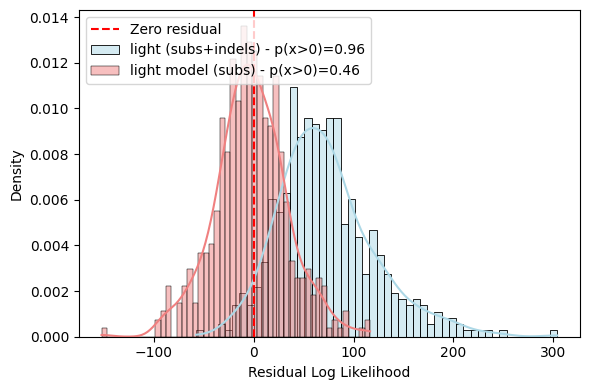

In [28]:
# plot histplot of residual likelihoods with vertical line at 0
fig, ax = plt.subplots(figsize=(6, 4))
for seqtype in ['light']:
    df_res = df_edges[(df_edges[f"n_ins_{seqtype}"] > 0) | (df_edges[f"n_del_{seqtype}"] > 0)]

    # calculate density above zero and add to plot
    p_pos = len(df_res[df_res[f"res_ll_{seqtype}"] > 0]) / len(df_res)
    p_pos_subs = len(df_res[df_res[f"res_sub_ll_{seqtype}"] > 0]) / len(df_res)

    sns.histplot(
        df_res[f"res_ll_{seqtype}"],
        bins=50,
        kde=True,
        label=f"{seqtype} (subs+indels) - p(x>0)={p_pos:.2f}",
        ax=ax,
        stat="density",
        color="lightblue",
    )
    sns.histplot(
        df_res[f"res_sub_ll_{seqtype}"],
        bins=50,
        kde=True,
        label=f"{seqtype} model (subs) - p(x>0)={p_pos_subs:.2f}",
        ax=ax,
        stat="density",
        color="lightcoral",
    )
    ax.axvline(0, color="red", linestyle="--", label="Zero residual")

ax.set_xlabel("Residual Log Likelihood")
ax.set_ylabel("Density")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [29]:
datasets = {
    k: EncodedPEINTDataset(
        dataset=CherriesDataset(data_file=data_files[k]),
        vocab=vocab,
        mask_prob=0.15,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
    )
    for k in modules.keys()
}
generators = {
    k: iter(
        PLMRDataModule(
            dataset=v,
            batch_size=32,
            shuffle=False,
        )._dataloader_template(dataset=v, training=False)
    )
    for k, v in datasets.items()
}

In [30]:
# measure entropy of decoded distribution as we increase the branch length
n_batches = len(next(iter(generators.values())))
entropies = defaultdict(list)

for i in tqdm(range(n_batches)):
    for j, seqtype in enumerate(modules.keys()):
        module = modules[seqtype]
        generator = generators[seqtype]
        batch = next(generator)
        batch = [b.to(device) for b in batch]
        [x, x_targets, y, y_targets, t, x_pad_mask, y_pad_mask] = batch

        yt_mask = y_targets != module.net.vocab.pad_idx  # actual values

        with torch.no_grad():
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                x_logits, y_logits = module(x, y, t, x_pad_mask, y_pad_mask)

        # Calculate probabilities predicted by the model
        y_probs = torch.softmax(y_logits, dim=-1)  # (bs, seq_len, vocab_size)

        # Calculate entropy per position: H = -∑(p * log(p))
        y_log_probs = torch.log_softmax(y_logits, dim=-1)
        entropy_per_site = -torch.sum(y_probs * y_log_probs, dim=-1)  # (bs, seq_len)
        entropy_per_site = entropy_per_site * yt_mask.float()

        sequence_entropy = entropy_per_site.sum(dim=-1) / yt_mask.sum(dim=-1)
        entropies[seqtype].append(sequence_entropy.detach().cpu().numpy())

100%|██████████████████████████████████████████████████████████████████████| 300/300 [01:17<00:00,  3.86it/s]


In [31]:
# save the entropies back into the dataframe
entrops = {k: np.concatenate(v) for k, v in entropies.items()}
for k, v in entrops.items():
    df_edges[f"entropy_{k}"] = v

In [38]:
# calculate the maximum entropy per site
vocab_size = len(vocab)
max_entropy = -np.log(1 / vocab_size)  # Maximum entropy for uniform distribution
print(f"Maximum entropy per site: {max_entropy:.4f}")

Maximum entropy per site: 3.4965


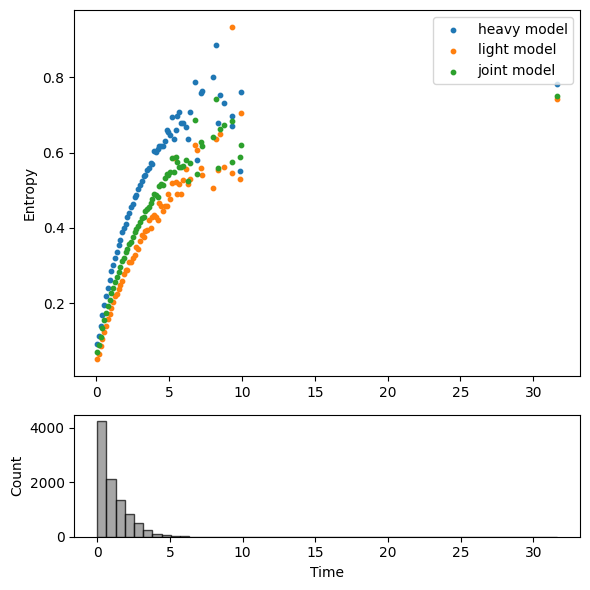

In [37]:
# scatter entropy vs branch length, hopefully larger branch lengths have higher entropy
df_edges["time_bin"] = df_edges.branch_length // df_edges.branch_length.quantile(0.1).astype(float)
bin_cols = ["time_bin", "branch_length"] + [f"entropy_{k}" for k in entrops.keys()]
binned_df = df_edges[bin_cols].groupby("time_bin").mean()

fig, (ax_main, ax_histx) = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(6, 6))

# Main scatter plot
for seqtype in entrops.keys():
    ax_main.scatter(
        binned_df.branch_length, binned_df[f"entropy_{seqtype}"], label=f"{seqtype} model", s=10
    )

ax_main.set_ylabel("Entropy")
ax_main.legend()

# Histogram on x-axis showing distribution of actual time values
ax_histx.hist(df_edges.branch_length, bins=50, alpha=0.7, color="gray", edgecolor="black")
ax_histx.set_ylabel("Count")
ax_histx.set_xlabel("Time")

plt.tight_layout()
plt.show()

## Check if distribution of indel lengths sampled from the model matches the distribution of indel lengths observed in the data

In [7]:
df_edges = pd.read_csv(data_dir / "peint_df.csv.gz", compression="gzip")
df_edges = df_edges[df_edges["sample_id"] == "d4"]
df_edges = df_edges[
    (df_edges.parent_heavy_aa != df_edges.child_heavy_aa)
    | (df_edges.parent_light_aa != df_edges.child_light_aa)
]
print(df_edges.shape)

for i in range(5):
    print(df_edges.iloc[i]["branch_length"], end=" ")
    print(datasets["heavy"][i][4])  # 4th is t

(9600, 51)
1.4165657723136795 1.4165657723136795
3.928860376069267 3.928860376069267
0.2038963736381347 0.2038963736381347
2.289122312441579 2.289122312441579
0.9847852163741 0.9847852163741001


In [8]:
df_edges["indel_length_heavy"] = df_edges.apply(lambda row: len(row.parent_heavy_aa) - len(row.child_heavy_aa), axis=1)
df_edges["indel_length_light"] = df_edges.apply(lambda row: len(row.parent_light_aa) - len(row.child_light_aa), axis=1)
df_edges["indel_length_joint"] = df_edges["indel_length_heavy"] + df_edges["indel_length_light"]

In [9]:
seqtype = "light"
module = modules[seqtype]
df_edges = df_edges[df_edges[f'indel_length_{seqtype}'] != 0]
df_edges.reset_index(drop=True, inplace=True)
print(df_edges.shape)

(504, 54)


In [10]:
# for each parent sequence in the dataframe, sample from PEINT and calculate the indel length
batch_size = 32
n_batches = min(40, (len(df_edges) + batch_size - 1) // batch_size)  # limit to 40 batches for speed
temperatures = [1.0]
sampled_sequences = []

for i in tqdm(range(n_batches)):
    df_batch = df_edges.iloc[i * 32 : (i + 1) * 32]
    parent_sequences = df_batch[f"parent_{seqtype}_aa"].tolist()
    branch_lengths = (df_batch["branch_length"] * 1).tolist()

    x_toks = torch.from_numpy(vocab.encode_batched_sequences(parent_sequences))
    time = torch.tensor(branch_lengths, dtype=torch.float32).unsqueeze(-1)

    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            sequences = module.net.generate(
                x=x_toks.to(device=device),
                t=time.to(device=device),
                device=device,
                max_decode_steps=1024,
                temperature=1,
                p=1.0,
            )
            decoded_sequences = module.net.decode_sequences(sequences)
    sampled_sequences.extend(decoded_sequences)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:29<00:00,  1.82s/it]


In [11]:
df_edges[f"sampled_child_{seqtype}_aa"] = pd.Series(sampled_sequences)
df_notna_edges = df_edges.dropna(subset=[f"sampled_child_{seqtype}_aa"])
print(df_notna_edges.shape)

(504, 55)


In [12]:
df_notna_edges[f"indel_length_sampled_{seqtype}"] = df_notna_edges.apply(
    lambda row: len(row[f"parent_{seqtype}_aa"]) - len(row[f"sampled_child_{seqtype}_aa"]), axis=1
)

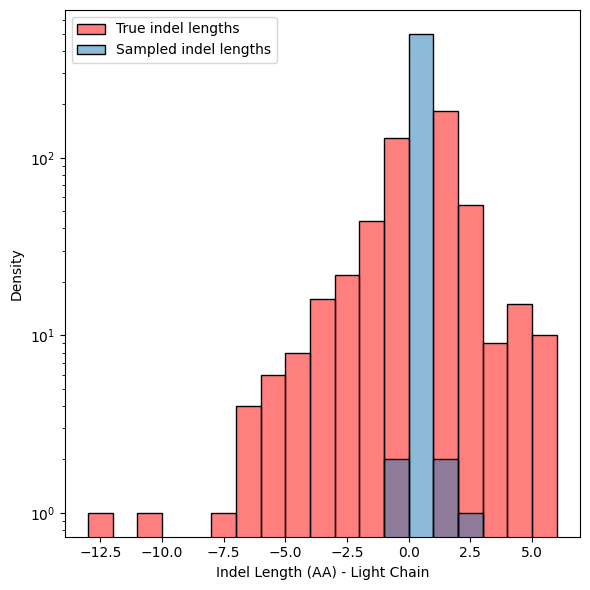

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sns.histplot(df_notna_edges[f"indel_length_{seqtype}"], ax=ax, color="red", label="True indel lengths", alpha=0.5, binwidth=1)
sns.histplot(df_notna_edges[f"indel_length_sampled_{seqtype}"], ax=ax, label=f"Sampled indel lengths", alpha=0.5, binwidth=1)
ax.set_xlabel(f"Indel Length (AA) - {seqtype.capitalize()} Chain")
ax.set_ylabel("Density")
ax.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

In [79]:
# Sample from tree using rejection sampling and check the distribution of sequence lengths at the leaves compared to the true leaf sequences
from evo.phylogeny import df_to_ete3_tree

data_dir = Path("/accounts/projects/yss/stephen.lu/protevo/plmr/data/wyatt/indels")
df_edges = pd.read_csv(data_dir / "full_df.csv.gz", compression="gzip")
print(df_edges.shape)

(64155, 36)


In [80]:
family = "d4_203694-igk-203694"
df_edges = df_edges[df_edges.family == family]
print(df_edges.shape)

(239, 36)


In [81]:
root_data

parent_heavy_aa    EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLE...
parent_light_aa    DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKL...
Name: 1942, dtype: object

In [82]:
tree = df_to_ete3_tree(df_edges[["parent_name", "child_name", "branch_length"]])

root_data = df_edges[df_edges.parent_name == "naive"].iloc[0][["parent_heavy_aa", "parent_light_aa"]]
root_seq = root_data.parent_heavy_aa + ("G" * 10) + root_data.parent_light_aa

leaf_data = df_edges[df_edges.child_name.str.contains("contig")][
    ["child_name", "child_heavy_aa", "child_light_aa"]
]
leaf_data["true"] = leaf_data.child_heavy_aa + ("G" * 10) + leaf_data.child_light_aa

In [83]:
print(tree.get_ascii())


                                                                          /-AAACGGGTCATTCACT-1-1279069_contig_h
                                                                    /Node13
                                                              /Node12     \-CAGATCAAGGACACCA-1-1287171_contig_h
                                                             |     |
                                                             |      \-GCCTCTAAGACTGGGT-1-1287174_contig_h
                                                             |
                                                             |                              /-ACATGGTAGGGCTTGA-1-1287170_contig_h
                                                             |                        /Node18
                                                             |                       |     |      /-ATCACGAGTACCCAAT-1-1279069_contig_h
                                                             |                       |      \Node19
 

In [84]:
simulation_args = {
    "model": modules["joint"],
    "vocab": vocab,
    "root_sequence": root_seq,
    "tree": tree,
    "device": device,
    "max_decode_steps": 1024,
    "max_batch_size": 128,
    "n_sequences": 4,
    "p_threshold": 1.0,
    "length_criterion": lambda x: x < 1024,
    "likelihood_fn": None,
    "max_retries": 3,
    "seed": 42,
}

In [87]:
for i in tqdm(range(5)):
    simulation_args["seed"] = i
    output = simulate_evolution_with_rejection_sampling(**simulation_args)
    sim_leaves = [output[node] for node in leaf_data.child_name]
    leaf_data["sim_{0}".format(i)] = sim_leaves

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [06:11<00:00, 74.25s/it]


In [89]:
leaf_data["true_length"] = leaf_data.true.str.len()
for i in tqdm(range(5)):
    leaf_data["sim_{0}_length".format(i)] = leaf_data["sim_{0}".format(i)].str.len()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 999.45it/s]


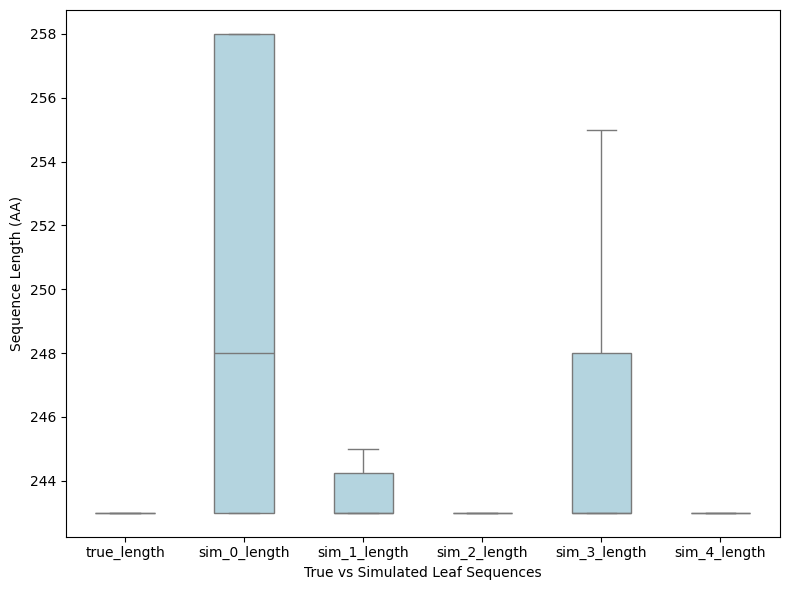

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.boxplot(
    pd.melt(
        leaf_data,
        value_vars=["true_length"] + ["sim_{0}_length".format(i) for i in range(5)],
        var_name="type",
        value_name="length",
    ),
    x="type",
    y="length",
    ax=ax,
    color="lightblue",
    showfliers=False,
    width=0.5,
)
ax.set_ylabel("Sequence Length (AA)")
ax.set_xlabel("True vs Simulated Leaf Sequences")
plt.tight_layout()
plt.show()
